In [21]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from mpl_toolkits.mplot3d import Axes3D
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [10]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [11]:
X = X_train[:3000]
y = y_train[:3000]

In [12]:
X = X.reshape(len(X), -1)

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [15]:
model = RandomForestClassifier()

model.fit(X_train_split, y_train_split)
y_pred = model.predict(X_test_split)

print("WITHOUT t-SNE Accuracy:", accuracy_score(y_test_split, y_pred))
print(classification_report(y_test_split, y_pred))

WITHOUT t-SNE Accuracy: 0.8383333333333334
              precision    recall  f1-score   support

           0       0.75      0.90      0.82        48
           1       1.00      0.99      0.99        67
           2       0.61      0.79      0.69        58
           3       0.88      0.91      0.89        54
           4       0.71      0.70      0.70        63
           5       0.88      0.98      0.93        54
           6       0.78      0.45      0.57        71
           7       0.95      0.89      0.92        62
           8       0.95      0.95      0.95        60
           9       0.91      0.92      0.91        63

    accuracy                           0.84       600
   macro avg       0.84      0.85      0.84       600
weighted avg       0.84      0.84      0.83       600



In [22]:
tsne = TSNE(n_components=3, random_state=42, perplexity=30)

X_tsne = tsne.fit_transform(X_scaled)

In [23]:
X_train_tsne, X_test_tsne, y_train_split, y_test_split = train_test_split(X_tsne, y, test_size=0.2, random_state=42)

In [24]:
model_tsne = RandomForestClassifier()
model_tsne.fit(X_train_tsne, y_train_split)

y_pred_tsne = model_tsne.predict(X_test_tsne)

print("\nWITH t-SNE Accuracy:", accuracy_score(y_test_split, y_pred_tsne))
print(classification_report(y_test_split, y_pred_tsne))


WITH t-SNE Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        48
           1       0.98      0.97      0.98        67
           2       0.58      0.62      0.60        58
           3       0.76      0.83      0.80        54
           4       0.60      0.62      0.61        63
           5       0.88      0.93      0.90        54
           6       0.51      0.39      0.44        71
           7       0.93      0.85      0.89        62
           8       0.91      0.87      0.89        60
           9       0.88      0.95      0.92        63

    accuracy                           0.78       600
   macro avg       0.78      0.79      0.78       600
weighted avg       0.78      0.78      0.78       600



In [25]:
print("\nKL Divergence:", tsne.kl_divergence_)


KL Divergence: 0.9839942455291748


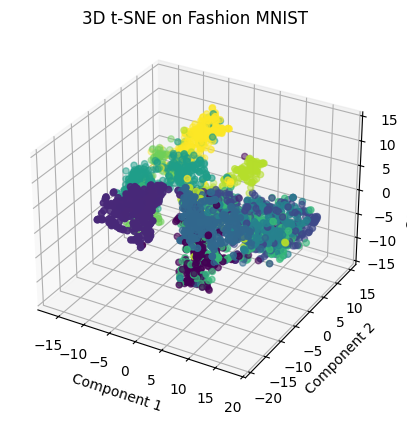

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    X_tsne[:, 2],
    c=y
)

ax.set_title("3D t-SNE on Fashion MNIST")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

plt.show()